# PM₂.₅ station forecast: reproducible audit companion

This notebook reads frozen derived outputs. It does not tune models or overwrite research results. It independently checks data quality, split integrity, model selection, held-out performance, uncertainty, high-event skill, and station transfer.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
assert (ROOT / 'config.json').exists(), ROOT
TABLES = ROOT / 'tables'
DERIVED = ROOT / 'data' / 'derived'
PROVENANCE = ROOT / 'provenance'
print('Experiment:', json.loads((ROOT / 'config.json').read_text())['experiment_name'])

Experiment: bmkg_pm25_station_cams_mos_v1


## 1. Observation quality and immutable-source accounting

In [2]:
obs = json.loads((PROVENANCE / 'observation_manifest.json').read_text())
quality = pd.read_csv(TABLES / 'data_quality_by_station.csv')
assert obs['source_files'] == 27 == obs['station_codes']
assert obs['conflicting_duplicate_keys'] == 0
pd.DataFrame([{
    'source_rows': obs['source_rows'],
    'unique_station_hours': obs['unique_station_hours'],
    'valid_pm25': obs['valid_pm25'],
    'valid_pm25_pct': obs['valid_pm25_pct'],
    'negative_pm25': obs['negative_pm25'],
    'pm25_at_or_above_985': obs['pm25_at_or_above_985'],
    'duplicate_rows_removed': obs['duplicate_rows_removed'],
}])

,source_rows,unique_station_hours,valid_pm25,valid_pm25_pct,negative_pm25,pm25_at_or_above_985,duplicate_rows_removed
0,1158532,1158490,1116030,96.331392,24858,17644,42


In [3]:
display(quality[['station_code','start_utc','end_utc','valid_pm25_pct_of_expected_hours','absent_hours_within_span','invalid_temperature']].sort_values('valid_pm25_pct_of_expected_hours'))

,station_code,start_utc,end_utc,valid_pm25_pct_of_expected_hours,absent_hours_within_span,invalid_temperature
9,PALU,2021-01-23T00:00:00+00:00,2026-08-31T23:00:00+00:00,42.556180,25203,0
16,PALANGKARAYA2,2021-01-01T00:00:00+00:00,2026-08-31T23:00:00+00:00,84.596021,4564,0
7,KOTOTABANG2,2021-09-24T06:00:00+00:00,2026-08-31T23:00:00+00:00,85.658485,1805,3662
26,TANJUNGHARAPAN2,2021-01-01T00:00:00+00:00,2026-08-31T23:00:00+00:00,88.094087,4513,0
24,SORONG,2021-08-19T06:00:00+00:00,2026-08-31T23:00:00+00:00,88.855654,2250,0
22,SINTANG,2021-09-19T09:00:00+00:00,2026-08-31T23:00:00+00:00,90.994168,496,0
17,PANGKALANBUN2,2021-09-24T15:00:00+00:00,2026-08-31T23:00:00+00:00,91.206048,1353,0
11,MAROS,2021-10-13T03:00:00+00:00,2026-08-31T23:00:00+00:00,91.299372,2070,0
20,SAMARINDA2,2021-01-01T00:00:00+00:00,2026-08-31T23:00:00+00:00,91.775415,1181,0
5,JAMBI3,2021-01-01T00:00:00+00:00,2026-08-31T23:00:00+00:00,92.808523,2479,0


## 2. Leakage and split audit

In [4]:
audit = json.loads((PROVENANCE / 'modeling_table_audit.json').read_text())
assert audit['duplicate_keys'] == 0
assert audit['negative_lag_feature_definitions'] == 0
assert audit['target_before_or_at_issue'] == 0
assert audit['train_validation_target_time_overlap'] == 0
assert audit['train_test_target_time_overlap'] == 0
assert audit['validation_test_target_time_overlap'] == 0
pd.Series(audit, name='value').to_frame()

,value
cams_complete_by_split_pct,"{'test': 100.0, 'train': 99.15387343567919, 'v..."
cams_complete_pct,99.463392
cams_complete_rows,215754
duplicate_keys,0
forecast_hours,"[3, 6, 12, 24, 48, 72]"
negative_lag_feature_definitions,0
rows,216918
split_rows,"{'test': 39366, 'train': 118422, 'validation':..."
split_valid_targets,"{'test': 36315, 'train': 111439, 'validation':..."
stations,27


## 3. Validation-only model selection

In [5]:
ranking = pd.read_csv(TABLES / 'model_selection_ranking.csv')
assert ranking.selected_champion.sum() == 1
champion = ranking.loc[ranking.selected_champion, 'model'].iloc[0]
print('Frozen champion:', champion)
display(ranking)

Frozen champion: cams_lgbm


,model,mean_station_balanced_mae_ug_m3,mean_skill_vs_persistence_pct,selected_champion
0,cams_lgbm,7.115967,28.728192,True
1,cams_xgboost,7.160143,28.024850,False
2,obs_lgbm,7.190489,28.312358,False


## 4. Independent 2026 test metrics

In [6]:
metrics = pd.read_csv(TABLES / 'metrics_summary.csv')
test = metrics.query("split == 'test' and scope == 'station_balanced_common_cases'")
display(test[test.model.isin(['persistence','climatology','raw_cams','obs_lgbm','cams_lgbm','cams_xgboost','champion'])].pivot(index='forecast_hour', columns='model', values='mae_ug_m3').round(2))

model,cams_lgbm,cams_xgboost,champion,climatology,obs_lgbm,persistence,raw_cams
forecast_hour,,,,,,,
3,7.62,7.61,7.62,10.60,7.84,12.64,9.95
6,6.29,6.30,6.29,9.04,6.61,14.18,7.91
12,10.50,10.56,10.50,12.84,10.72,16.69,17.61
24,10.84,10.88,10.84,13.66,10.87,13.11,17.51
48,11.66,11.67,11.66,13.73,11.78,13.90,18.10
72,12.03,12.12,12.03,13.73,12.17,14.68,18.55


In [7]:
bootstrap = pd.read_csv(TABLES / 'block_bootstrap_skill.csv').query("model == 'champion'")
display(bootstrap[['forecast_hour','mae_improvement_ug_m3','ci95_lower_ug_m3','ci95_upper_ug_m3','n_station_weeks']].round(2))
cams_increment = pd.read_csv(TABLES / 'cams_incremental_skill_vs_observation_ml.csv', dtype={'forecast_hour': str})
display(cams_increment.query("split == 'test'")[['forecast_hour','cams_mae_improvement_over_obs_ml_ug_m3','ci95_lower_ug_m3','ci95_upper_ug_m3','bootstrap_probability_positive_pct']].round(3))

,forecast_hour,mae_improvement_ug_m3,ci95_lower_ug_m3,ci95_upper_ug_m3,n_station_weeks
5,3,5.01,3.79,6.29,945
11,6,8.34,7.26,9.59,943
17,12,6.88,5.77,8.14,944
23,24,1.78,1.02,2.45,943
29,48,2.04,0.99,3.10,941
35,72,2.38,1.16,3.50,941


,forecast_hour,cams_mae_improvement_over_obs_ml_ug_m3,ci95_lower_ug_m3,ci95_upper_ug_m3,bootstrap_probability_positive_pct
7,3,0.295,0.194,0.394,100.0
8,6,0.390,0.286,0.489,100.0
9,12,0.240,0.165,0.315,100.0
10,24,0.012,-0.179,0.184,56.0
11,48,0.045,-0.057,0.143,82.9
12,72,0.089,-0.033,0.222,92.8
13,all,0.178,0.119,0.242,100.0


## 5. Prediction intervals and high-concentration events

In [8]:
intervals = pd.read_csv(TABLES / 'prediction_interval_metrics.csv').query("split == 'test'")
events = pd.read_csv(TABLES / 'high_event_detection_metrics.csv')
display(intervals[['forecast_hour','n','empirical_coverage_pct','mean_interval_width_ug_m3','mean_interval_score_ug_m3']].round(2))
display(events[['forecast_hour','hits','misses','false_alarms','probability_of_detection_pct','false_alarm_ratio_pct','critical_success_index_pct']].round(2))

,forecast_hour,n,empirical_coverage_pct,mean_interval_width_ug_m3,mean_interval_score_ug_m3
0,3,6050,79.40,19.83,42.32
1,6,5905,79.27,17.67,32.97
2,12,6108,81.12,33.96,53.00
3,24,6084,78.02,31.72,53.36
4,48,6084,77.50,32.31,57.58
5,72,6084,77.53,32.46,60.60


,forecast_hour,hits,misses,false_alarms,probability_of_detection_pct,false_alarm_ratio_pct,critical_success_index_pct
0,3,392,322,148,54.90,27.41,45.48
1,6,403,314,125,56.21,23.67,47.86
2,12,225,475,85,32.14,27.42,28.66
3,24,357,423,148,45.77,29.31,38.47
4,48,280,500,153,35.90,35.33,30.01
5,72,252,528,154,32.31,37.93,26.98


## 6. Spatial transfer and training-window sensitivity

In [9]:
transfer = pd.read_csv(TABLES / 'station_transfer_metrics.csv')
transfer_summary = transfer.groupby('forecast_hour').agg(stations=('station_code','nunique'), mae_ug_m3=('mae_ug_m3','mean'), skill_vs_persistence_pct=('skill_vs_persistence_pct','mean')).round(2)
display(transfer_summary)
sensitivity = pd.read_csv(TABLES / 'recent_window_sensitivity.csv')
display(sensitivity.query("scope == 'station_balanced_common_cases' and model in ['recent_window','champion']"))

,stations,mae_ug_m3,skill_vs_persistence_pct
forecast_hour,,,
3,27,7.78,34.99
6,27,6.50,46.37
12,27,11.29,25.60
24,27,11.09,14.06
48,27,11.98,13.01
72,27,12.42,14.42


,n,mae_ug_m3,rmse_ug_m3,bias_ug_m3,correlation,r2,split,forecast_hour,model,scope,skill_vs_persistence_pct,n_stations,training_window
1,5918,7.852997,17.154902,-2.873131,0.715682,0.454933,test,3,recent_window,station_balanced_common_cases,34.714491,27.0,2024_only
3,5753,6.632988,14.490901,-1.524855,0.692036,0.426311,test,6,recent_window,station_balanced_common_cases,45.810154,27.0,2024_only
5,5897,10.991353,17.708568,-2.556824,0.543194,0.257722,test,12,recent_window,station_balanced_common_cases,30.267237,27.0,2024_only
7,5859,11.278404,20.726787,-3.805967,0.652112,0.343095,test,24,recent_window,station_balanced_common_cases,14.939294,27.0,2024_only
9,5839,12.014612,22.156951,-4.477151,0.588866,0.253282,test,48,recent_window,station_balanced_common_cases,14.666256,27.0,2024_only
11,5832,12.389901,22.699398,-4.809544,0.556626,0.212244,test,72,recent_window,station_balanced_common_cases,16.677975,27.0,2024_only
12,5918,7.615650,16.484508,-2.364068,0.726515,0.469372,test,3,champion,station_balanced_common_cases,36.485112,27.0,2023_2024_frozen_champion
14,5753,6.290049,13.438005,-1.576551,0.716466,0.476537,test,6,champion,station_balanced_common_cases,47.971175,27.0,2023_2024_frozen_champion
16,5897,10.504597,16.615793,-2.228063,0.581410,0.316665,test,12,champion,station_balanced_common_cases,32.901406,27.0,2023_2024_frozen_champion
18,5859,10.836499,19.554585,-3.430218,0.658016,0.383234,test,24,champion,station_balanced_common_cases,17.553120,27.0,2023_2024_frozen_champion


## 7. Rendered evidence

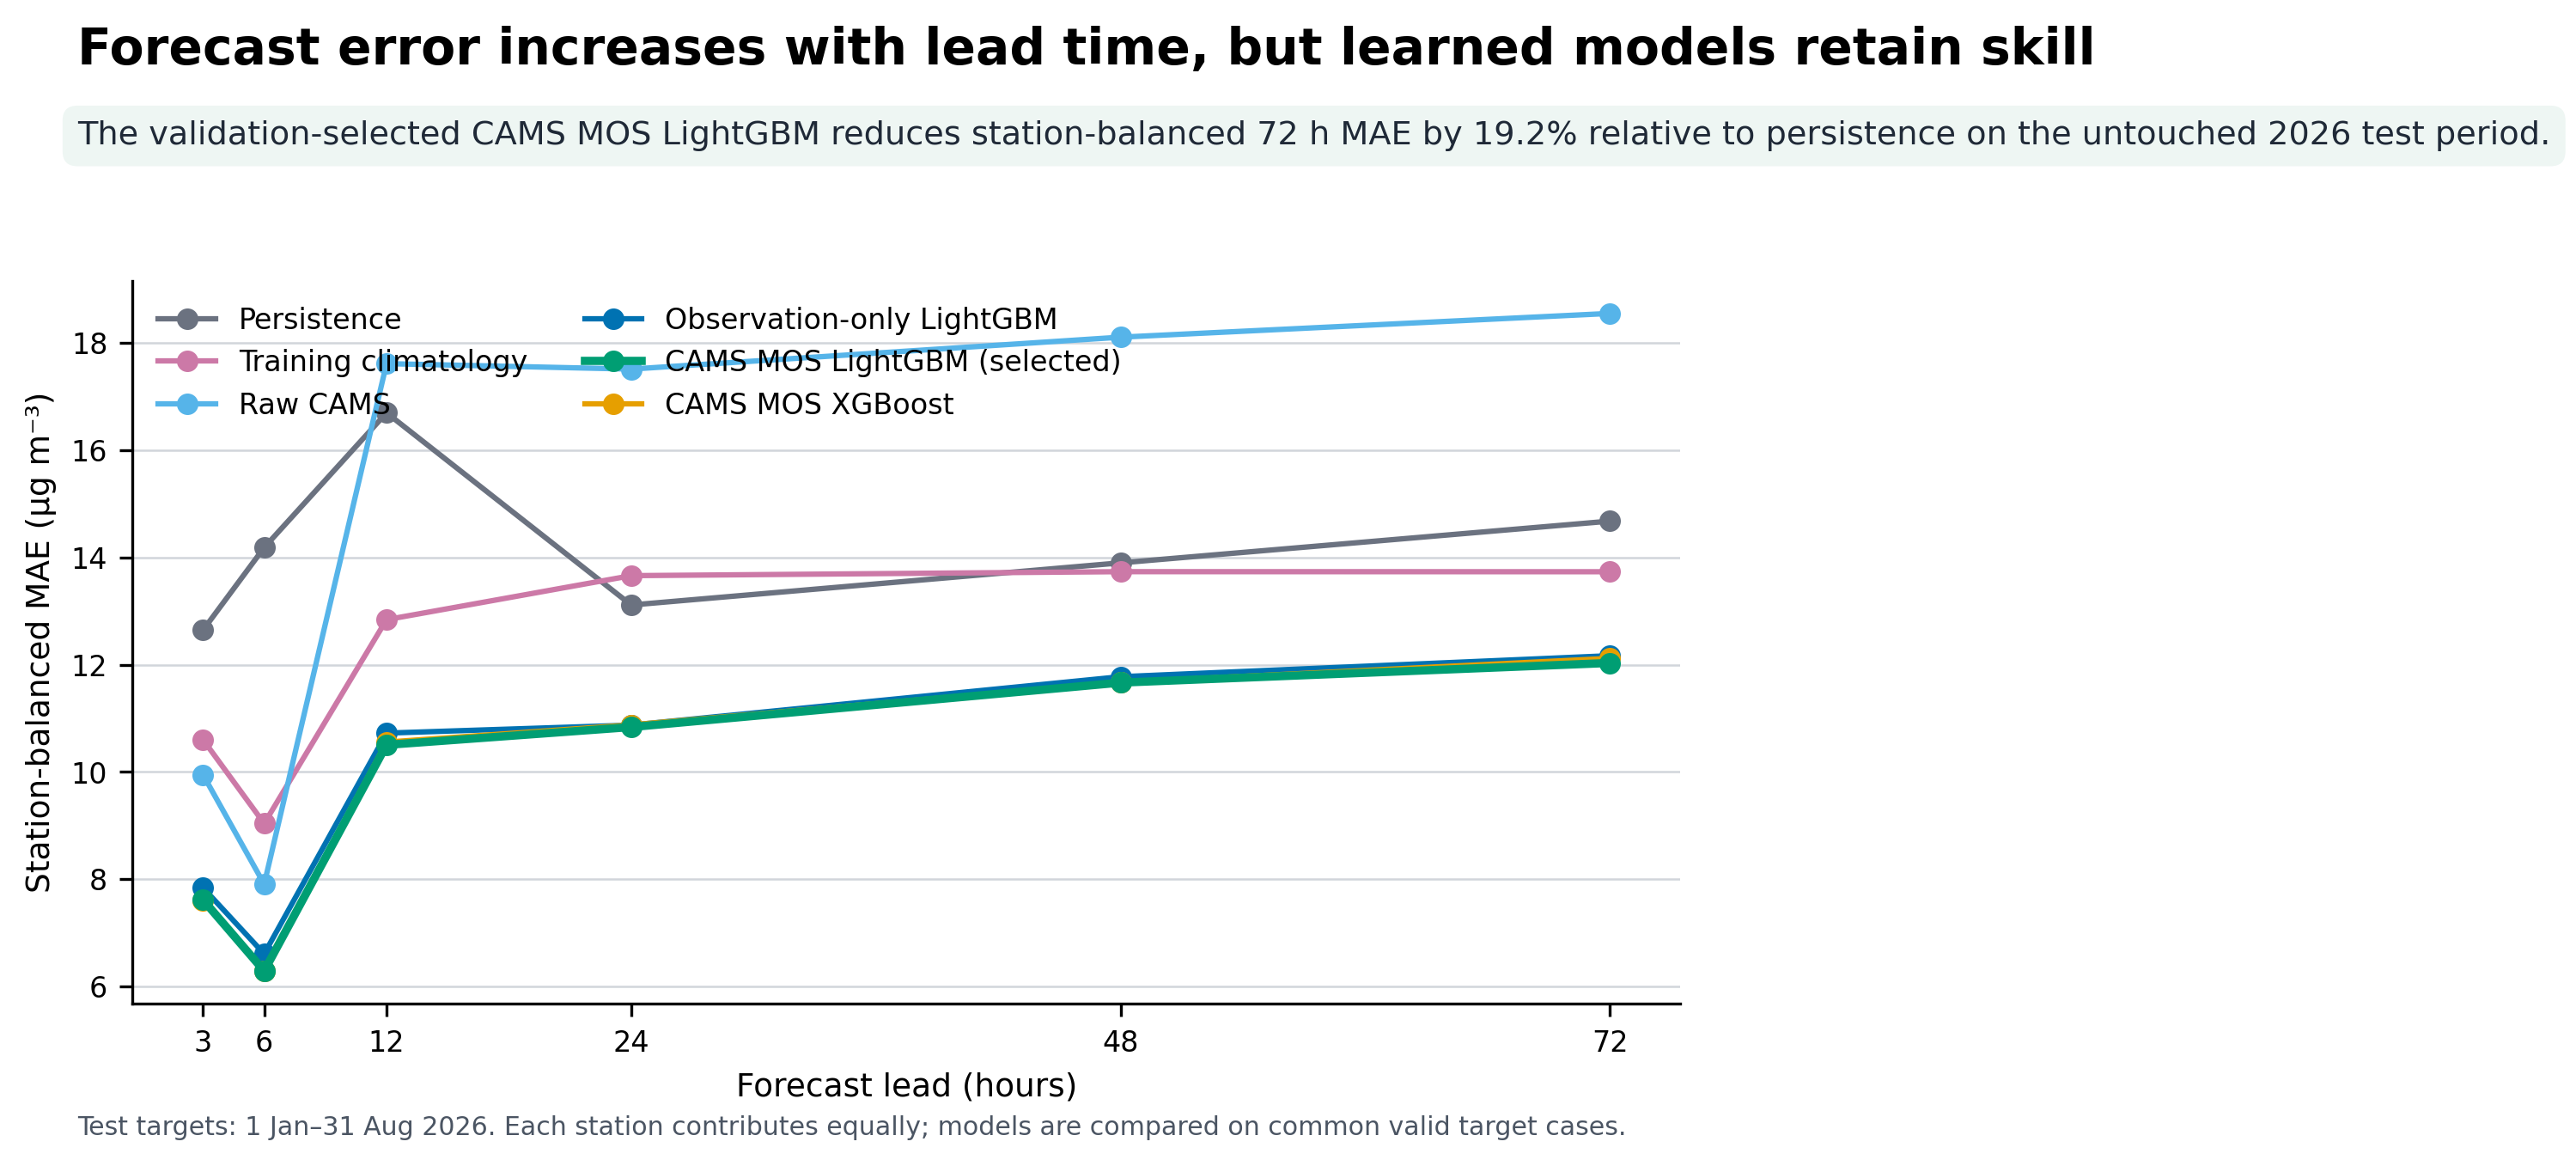

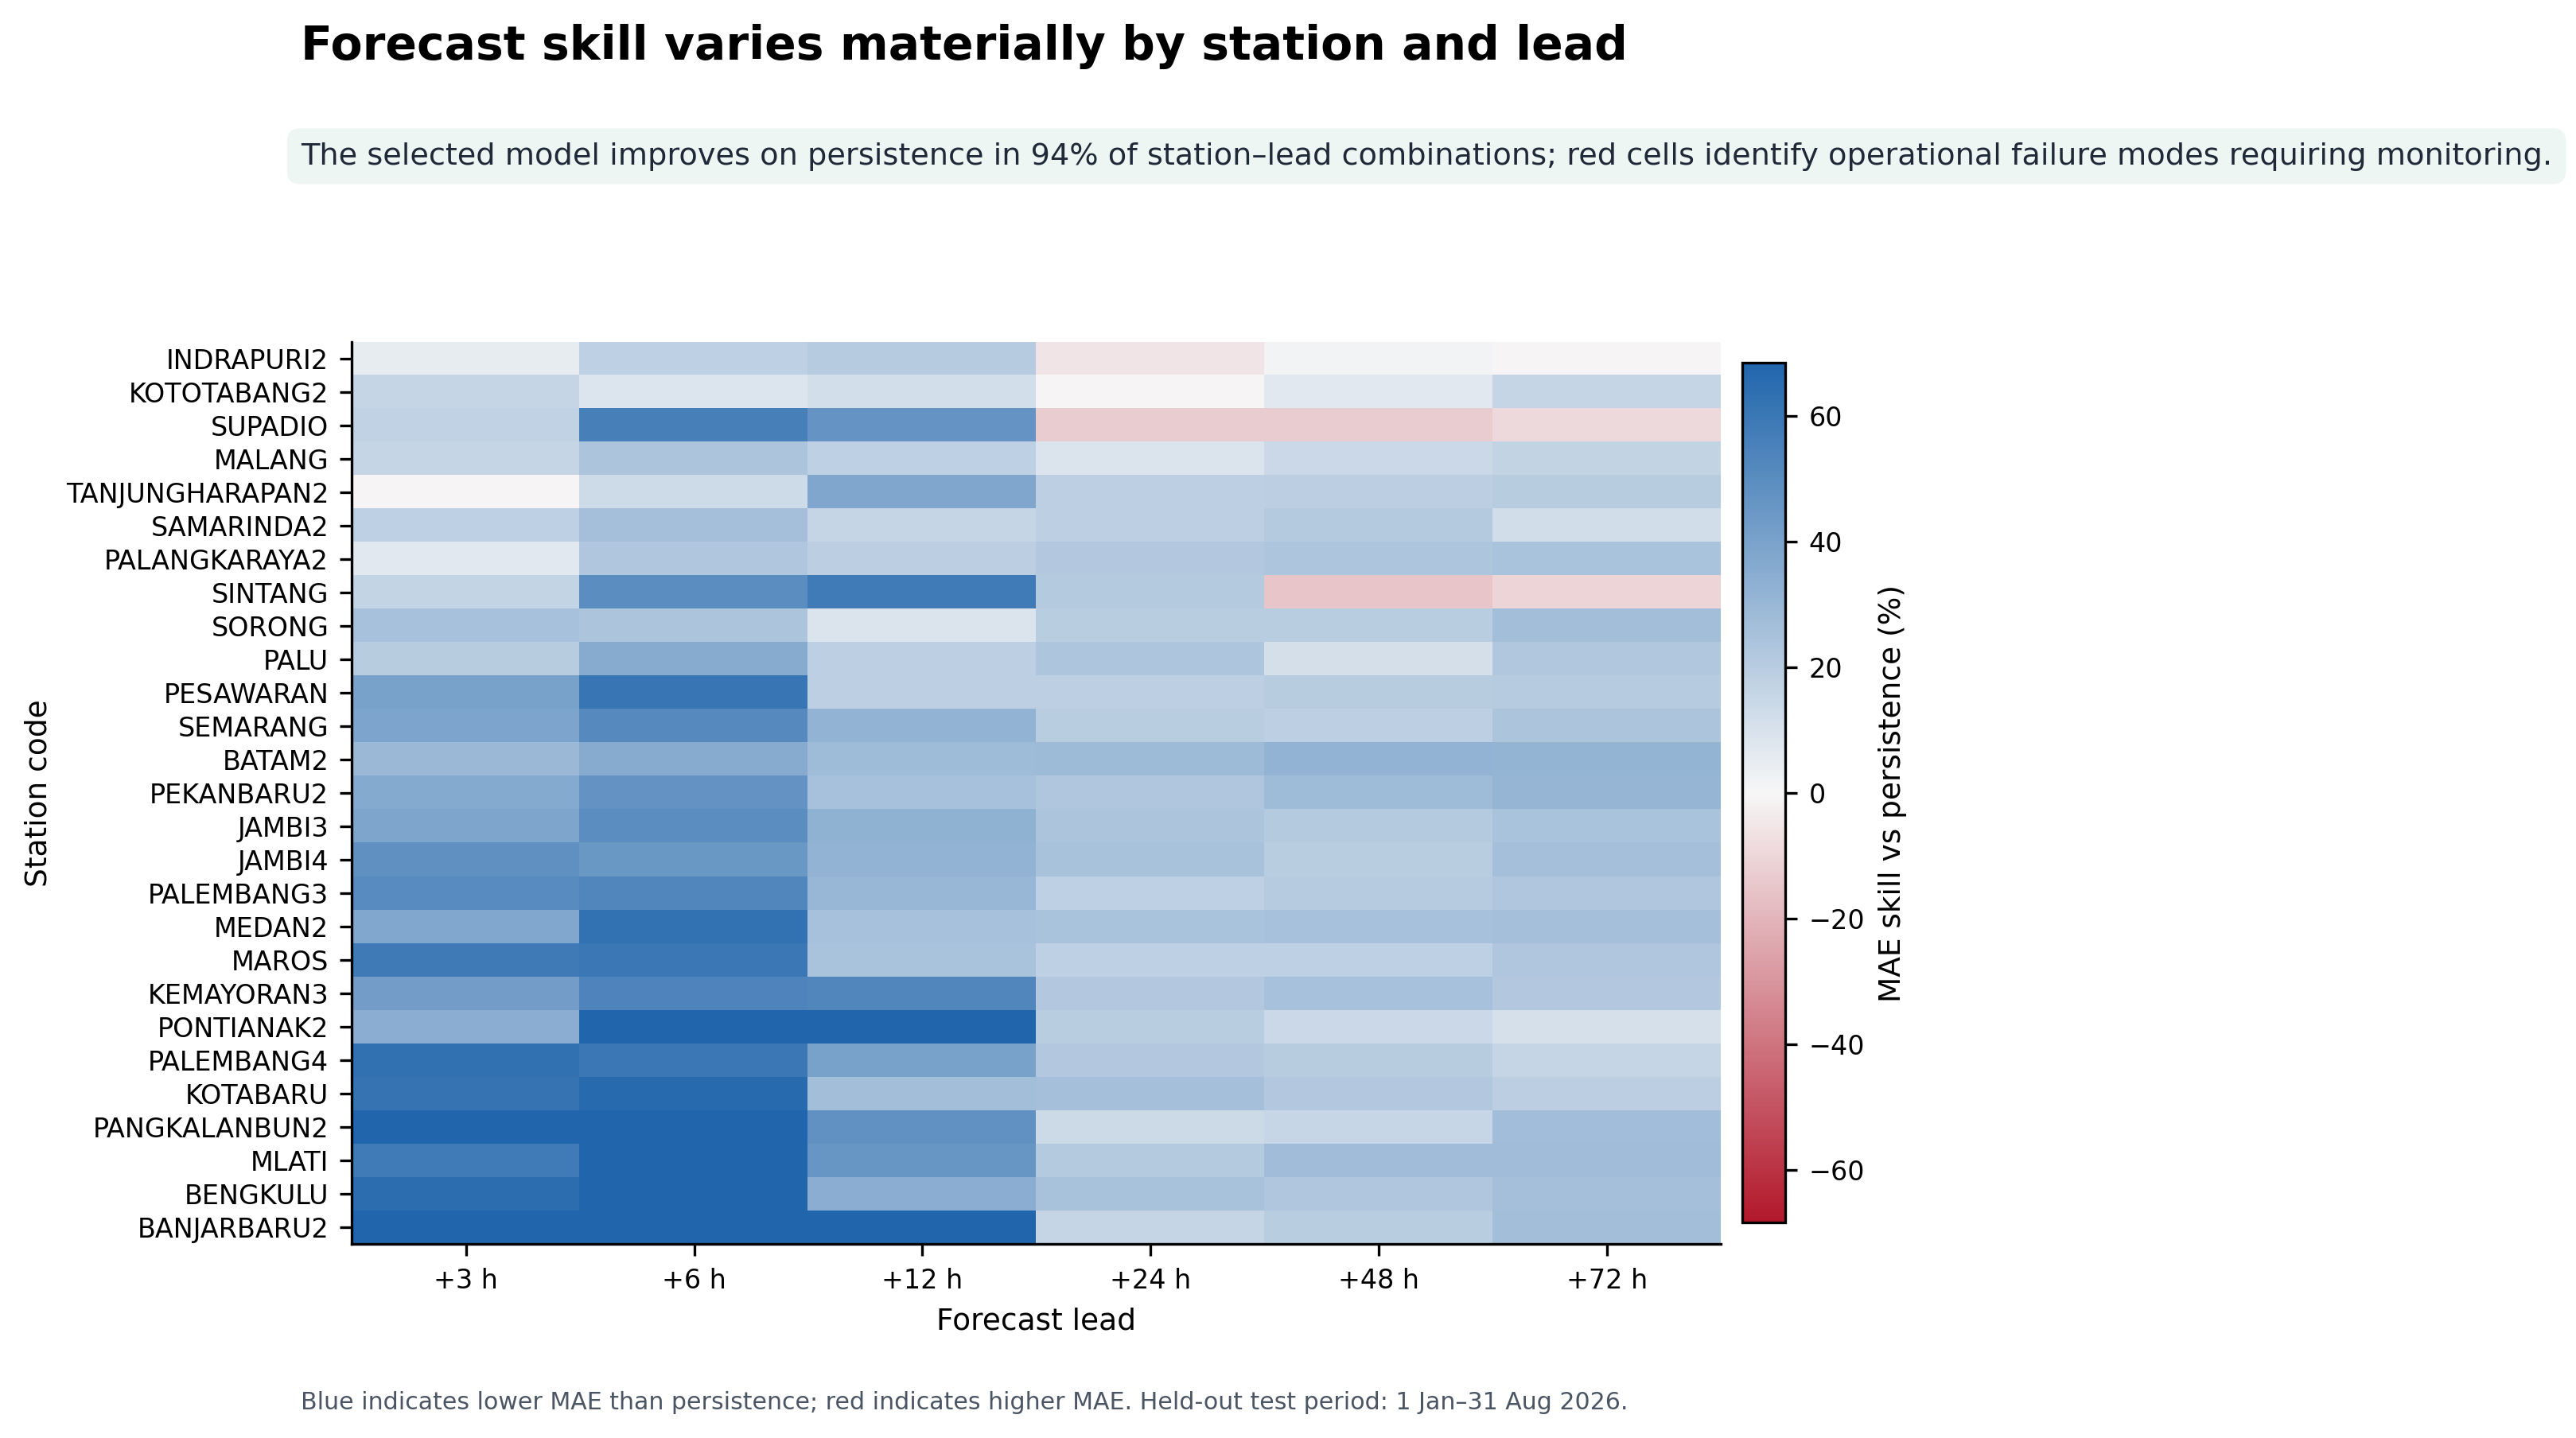

In [10]:
display(Image(filename=str(ROOT / 'figures' / 'figure_02_test_performance.png'), width=850))
display(Image(filename=str(ROOT / 'figures' / 'figure_03_station_skill.png'), width=850))

## Interpretation boundary

Passing these checks supports retrospective predictive evaluation at the represented stations and issue cycle. It does not establish causal attribution, continuous spatial-map validity, prospective operational reliability, or equal skill at every station.